In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))
from renormalization import (
    rg_step,
    required_initial_max_distance,
    construct_transfer_matrix,
)
from utils import build_J, build_K, build_Delta

In [2]:
def generate_rg_flow(J0, K0, Delta0, a,
                     max_dist_final, n_steps,
                     trace_TM=False, TM_r=1,
                     delta_long_range=True,
                     r_max_cap=None):
    """Run the PLG RG flow for n_steps iterations and return the coupling
    vectors at every step plus (optionally) transfer matrices.

    Parameters
    ----------
    J0, K0, Delta0 : float
        Bare couplings at r=1.
    a : float
        Power-law range exponent (common to J, K, Delta by default).
    max_dist_final : int
        We want the final J/K/Delta vectors to still reach this r.
    n_steps : int
        Number of RG iterations.
    trace_TM : bool
        If True, also record the 4x4 transfer matrix at distance TM_r
        at each step.
    r_max_cap : int or None
        Maximum distance at which to compute the exact (head) decimation.
        Distances beyond this are filled via power-law tail continuation.
        Defaults to max(max_dist_final + 4, 3 * max_dist_final) which is
        plenty for plotting and much faster than the geometric r_max
        (which grows as 3^n_steps).

    Returns
    -------
    couplings : dict with keys 'J', 'K', 'Delta' each mapping to a list
        of length n_steps+1 containing the coupling vector at each step.
    TM_list : list of 4x4 np.ndarray (one per step) or None if trace_TM=False.
    """
    D0 = required_initial_max_distance(max_dist_final, n_steps)

    if r_max_cap is None:
        r_max_cap = max(max_dist_final + 4, 3 * max_dist_final)

    J = build_J(J0, a, D0)
    K = build_K(K0, a, D0)
    Delta = build_Delta(Delta0, a, D0, long_range=delta_long_range)

    J_list = [J.copy()]
    K_list = [K.copy()]
    D_list = [Delta.copy()]
    TM_list = [] if trace_TM else None

    for step in range(n_steps + 1):
        if trace_TM and TM_r < len(J):
            T = construct_transfer_matrix(J, K, Delta, TM_r, normalize=True)
            TM_list.append(T)

        if step == n_steps:
            break

        J, K, Delta = rg_step(J, K, Delta, a=a, r_max_cap=r_max_cap)
        J_list.append(J.copy())
        K_list.append(K.copy())
        D_list.append(Delta.copy())

    couplings = {'J': J_list, 'K': K_list, 'Delta': D_list}
    return couplings, TM_list


def extract_flows(couplings, max_dist_final):
    """Convert list-of-vectors storage into rectangular arrays of shape
    (n_steps+1, max_dist_final+1), one per coupling family.

    Returns a dict {'J': ..., 'K': ..., 'Delta': ...}.
    """
    out = {}
    for name, vec_list in couplings.items():
        n = len(vec_list)
        flows = np.zeros((n, max_dist_final + 1), dtype=float)
        for step, V in enumerate(vec_list):
            D_curr = len(V) - 1
            r_max_rec = min(max_dist_final, D_curr)
            flows[step, :r_max_rec + 1] = V[:r_max_rec + 1]
        out[name] = flows
    return out


def plot_rg_flow(flows_dict, distances_to_plot=None,
                 families=('J', 'K', 'Delta'),
                 fig_name=None, sharex=True):
    """Plot the RG flow of the chosen coupling families vs iteration number,
    one subplot per family.

    flows_dict : dict output of extract_flows()
    distances_to_plot : iterable of int r's, or None for all r>=1
    families : subset of ('J', 'K', 'Delta')
    """
    n_fam = len(families)
    fig, axes = plt.subplots(1, n_fam, figsize=(5 * n_fam, 4.2), sharex=sharex)
    if n_fam == 1:
        axes = [axes]

    # Figure out default distances from the first family
    first = flows_dict[families[0]]
    _, max_dist_plus_1 = first.shape
    max_dist = max_dist_plus_1 - 1
    if distances_to_plot is None:
        distances_to_plot = list(range(1, max_dist + 1))

    ylabels = {
        'J': r"$J_r$  (Potts coupling)",
        'K': r"$K_r$  (pair/biquadratic)",
        'Delta': r"$\Delta_r$  (chemical potential)",
    }

    for ax, fam in zip(axes, families):
        flows = flows_dict[fam]
        n_steps_plus_1 = flows.shape[0]
        steps = np.arange(n_steps_plus_1)
        for r in distances_to_plot:
            if 1 <= r <= max_dist:
                ax.plot(steps, flows[:, r], marker='o', markersize=4,
                        label=f"${r}$")
        ax.set_xlim(0, None)
        ax.set_xlabel(r"RG iteration $k$", fontsize=12)
        ax.set_ylabel(ylabels[fam], fontsize=12)
        ax.axhline(0.0, color='0.7', lw=0.8, ls='--')
        ax.grid(alpha=0.3)

    axes[-1].legend(title=r"$r$", title_fontsize=11, fontsize=9,
                    loc='best', ncol=1)

    plt.tight_layout()
    if fig_name:
        plt.savefig("../results/" + fig_name, dpi=150)
    return fig, axes


[[0.3679 0.3679 0.3679 0.3679]
 [0.3679 1.     0.3679 0.3679]
 [0.3679 0.3679 1.     0.3679]
 [0.3679 0.3679 0.3679 1.    ]]

[[0.0339 0.1061 0.1061 0.1061]
 [0.1061 1.     0.3809 0.3809]
 [0.1061 0.3809 1.     0.3809]
 [0.1061 0.3809 0.3809 1.    ]]

[[0.000e+00 1.000e-04 1.000e-04 1.000e-04]
 [1.000e-04 1.000e+00 3.811e-01 3.811e-01]
 [1.000e-04 3.811e-01 1.000e+00 3.811e-01]
 [1.000e-04 3.811e-01 3.811e-01 1.000e+00]]

[[0.     0.     0.     0.    ]
 [0.     1.     0.4164 0.4164]
 [0.     0.4164 1.     0.4164]
 [0.     0.4164 0.4164 1.    ]]

[[0.     0.     0.     0.    ]
 [0.     1.     0.4833 0.4833]
 [0.     0.4833 1.     0.4833]
 [0.     0.4833 0.4833 1.    ]]

[[0.     0.     0.     0.    ]
 [0.     1.     0.5686 0.5686]
 [0.     0.5686 1.     0.5686]
 [0.     0.5686 0.5686 1.    ]]


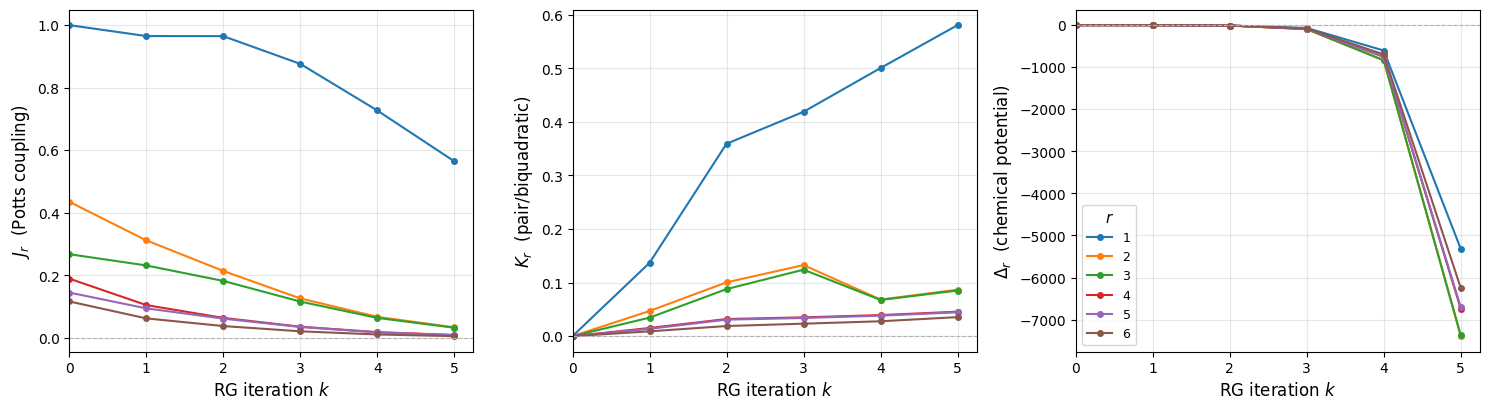

In [3]:
J0 = 1
K0 = 0.0
Delta0 = 0.0

a = 1.2

max_dist_final = 10
n_steps = 5

couplings, T_list = generate_rg_flow(J0, K0, Delta0, a, max_dist_final=max_dist_final, n_steps=n_steps, trace_TM=True, TM_r=1,)

flows = extract_flows(couplings, max_dist_final)

plot_rg_flow(flows, distances_to_plot=[1, 2, 3, 4, 5, 6,],
    #fig_name="rg_flow_order.png",
)

for i, T in enumerate(T_list):
    print()
    print(np.round(T, 4))